In [2]:
import os
import sys
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
import shap
import torch
sys.path.insert(0, os.path.abspath('..'))
from scripts.models.nn.classes.factory import build_model
from scripts.models.nn.classes.dataset import load_split
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100,'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FEATDIR    = CONFIGS['filepaths']['features']
WEIGHTDIR  = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
NNCFG      = MODELS['nn']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'valid'
PREDVARS   = ['rh','thetae','thetaestar']
NAMEB      = 'baseline_rh_thetae_thetaestar_lf_lhf_shf'
NAMEK      = 'nonparametric_rh_thetae_thetaestar_lf_lhf_shf'
N_BG       = 200
N_EX       = 500
NSAMP      = 256
VARLABELS  = {
    'rh':r'$RH$',
    'thetae':r'$\theta_e$',
    'thetaestar':r'$\theta_e^*$',
    'lhf':'Latent Heat Flux',
    'shf':'Sensible Heat Flux',
    'lf':'Land Fraction'}

In [4]:
ds       = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf')
target   = ds.tp.load()
inputs   = {v:ds[v].load() for v in ['rh','thetae','thetaestar','lhf','shf','lf']}
sp       = ds.ps.load()
landmask = inputs['lf']>0.5

results = []
for name,_ in MODELS['nn']['runs'].items():
    if name.startswith('nonparametric_rh') or name.startswith('baseline_rh'):
        filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
        if os.path.exists(filepath):
            output  = xr.open_dataset(filepath).tp.load()
            aligned = xr.align(target,output,*inputs.values(),join='inner')
            ytrue   = aligned[0]
            ypred   = aligned[1]
            xlist   = dict(zip(inputs.keys(),aligned[2:]))
            results.append((name,ytrue,ypred,xlist))

preds = {}
for name in [NAMEB,NAMEK]:
    fpath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if os.path.exists(fpath):
        preds[name] = xr.open_dataset(fpath).tp.load()

resid_b     = (target-preds[NAMEB]).mean('seed').squeeze()
resid_k     = (target-preds[NAMEK]).mean('seed').squeeze()
delta_resid = resid_k-resid_b

weights  = xr.open_dataset(os.path.join(WEIGHTDIR,f'{NAMEK}_{SPLIT}_weights.nc')).load()
features = xr.open_dataset(os.path.join(FEATDIR,f'{NAMEK}_{SPLIT}_features.nc')).load()
LEVELS   = weights['lev'].values
wmean    = {v:weights['k1'].sel(field=v).mean('seed') for v in PREDVARS}
wstd     = {v:weights['k1'].sel(field=v).std('seed')  for v in PREDVARS}
fmean    = {v:features[v].mean('seed')                for v in PREDVARS}

fieldvars_shap = PREDVARS
localvars_shap = ['lf','lhf','shf']
F,L,Y,dlev,nlevs,_,valid_shap,ref = load_split(
    SPLIT,fieldvars_shap,localvars_shap,SPLITSDIR,targetvar='tp')
nfv,nlv   = len(fieldvars_shap),len(localvars_shap)
X_shap    = np.hstack([F.numpy().reshape(len(F),-1),L.numpy()])
is_land_shap = L[:,0].numpy()>0.5

vcols = {}
for i,v in enumerate(fieldvars_shap):
    vcols[v] = slice(i*nlevs,(i+1)*nlevs)
for j,v in enumerate(localvars_shap):
    vcols[v] = slice(nfv*nlevs+j,nfv*nlevs+j+1)

In [5]:


def compute_skill_vs_bins(results,varname,landmask,nbins=10):
    _,ytrueb,ypredb,xlistb = results[0]
    _,ytruek,ypredk,xlistk = results[1]
    predictor = xlistb[varname]
    pred2d    = predictor.mean(dim=[d for d in predictor.dims if d not in ('time','lat','lon')])
    r2b       = get_r2(ytrueb,ypredb,dims=['time']).mean('seed').squeeze()
    r2k       = get_r2(ytruek,ypredk,dims=['time']).mean('seed').squeeze()
    delta     = r2k-r2b
    predmean  = pred2d.mean('time') if 'time' in pred2d.dims else pred2d
    return bin_land_ocean(
        predmean.values.ravel(),
        delta.values.ravel(),
        (landmask.values if hasattr(landmask,'values') else landmask).ravel().astype(bool),
        nbins=nbins)

In [8]:
def error_decomposition(sv, y_true, y_pred, vcols):
    """Distribute squared error at each point proportionally to |SHAP|
    so that feature contributions sum to MSE."""
    sq_err = (y_pred - y_true) ** 2
    abs_sv = np.abs(sv)
    total = abs_sv.sum(axis=1, keepdims=True)
    total = np.where(total == 0, 1, total)
    weighted = abs_sv / total * sq_err[:, np.newaxis]
    return {v: weighted[:, vcols[v]].sum(axis=1).mean() for v in vcols}


def plot_shap_attribution(sv_bl, sv_bo, sv_kl, sv_ko,
                           y_land, y_ocean,
                           yhat_bl, yhat_bo, yhat_kl, yhat_ko,
                           vcols, allvars):
    labels = [VARLABELS.get(v, v) for v in allvars]
    xp     = np.arange(len(allvars))
    w      = 0.18

    ed_bl = error_decomposition(sv_bl, y_land, yhat_bl, vcols)
    ed_bo = error_decomposition(sv_bo, y_ocean, yhat_bo, vcols)
    ed_kl = error_decomposition(sv_kl, y_land, yhat_kl, vcols)
    ed_ko = error_decomposition(sv_ko, y_ocean, yhat_ko, vcols)

    fig, axs = pplt.subplots(ncols=2, refwidth=3.2, share=False)

    for i, (mlabel, edl, edo) in enumerate([('Baseline', ed_bl, ed_bo),
                                              ('Kernel',   ed_kl, ed_ko)]):
        for j, (stype, ed, c) in enumerate([('Land', edl, 'sienna'),
                                              ('Ocean', edo, 'steelblue')]):
            vals = [ed[v] for v in allvars]
            axs[0].bar(xp + (i * 2 + j - 1.5) * w, vals, width=w, color=c,
                       alpha=0.5 + 0.25 * i, label=f'{mlabel} {stype}')

    axs[0].set_xticks(xp)
    axs[0].set_xticklabels(labels, rotation=30, ha='right')
    axs[0].format(ylabel='MSE Contribution',
                  title='(a) Error Decomposition by Feature', grid=True)
    axs[0].legend(loc='ur', ncols=1, fontsize=7)

    diff_land  = {v: ed_kl[v] - ed_bl[v] for v in vcols}
    diff_ocean = {v: ed_ko[v] - ed_bo[v] for v in vcols}

    axs[1].bar(xp - 0.15, [diff_land[v]  for v in allvars], width=0.28,
               color='sienna',   label='Land')
    axs[1].bar(xp + 0.15, [diff_ocean[v] for v in allvars], width=0.28,
               color='steelblue', label='Ocean')
    axs[1].axhline(0, color='k', lw=0.8, ls='--')
    axs[1].set_xticks(xp)
    axs[1].set_xticklabels(labels, rotation=30, ha='right')
    axs[1].format(ylabel=r'$\Delta$ MSE Contribution (Kernel $-$ Baseline)',
                  title='(b) Change in Error Attribution', grid=True)
    axs[1].legend(loc='lr', ncols=1, fontsize=7)

    fig.format(suptitle='SHAP Error Decomposition: Feature Contributions to MSE')
    pplt.show()




In [13]:
# plot_r2_maps(results)

In [12]:
# plot_skill_vs_predictors(results,landmask,varnames=VARLABELS,nbins=10)

In [11]:
# plot_kernel_weights(wmean,wstd,LEVELS)

In [9]:
# plot_feature_variance(fmean,landmask)

In [10]:
# plot_residual_vs_sp(delta_resid,sp,landmask)

## SHAP-Based Error Decomposition & M-Plots

We use **kernel SHAP** to decompose each model's MSE into per-feature contributions. For each sample $i$ and feature group $j$, the error attribution is:

$$\text{err}_{j,i} = \frac{|\phi_{j,i}|}{\sum_k |\phi_{k,i}|} \cdot (y_i - \hat{y}_i)^2$$

so that feature contributions sum to the MSE (matching the training loss). This directly answers "how much of the squared error comes from each feature?" Panel (a) shows the error decomposition for each model/surface combination, and panel (b) shows the change in error attribution (kernel $-$ baseline).

**M-plots** (conditional average plots) complement this by plotting ground-truth precipitation alongside both models' predictions as a function of each feature — all conditioned on the same bin edges and aligned to common coordinates — revealing precisely where each model deviates from observations.

In [14]:
rng = np.random.default_rng(42)

def _load_model(name):
    rc  = NNCFG['runs'][name]
    mdl = build_model(name,rc,nlevs)
    mdl.load_state_dict(torch.load(
        os.path.join(MODELSDIR,'nn',f'{name}_42.pth'),
        map_location='cpu',weights_only=True))
    mdl.eval()
    return mdl,rc['kind'] not in ('baseline','hurdle')

model_base,hk_base = _load_model(NAMEB)
model_kern,hk_kern = _load_model(NAMEK)

def _make_predict_fn(mdl,haskernel):
    def predict(Xin):
        Xin = np.atleast_2d(Xin).astype(np.float32)
        n   = Xin.shape[0]
        ft  = torch.from_numpy(Xin[:,:nfv*nlevs].reshape(n,nfv,nlevs))
        lt  = torch.from_numpy(Xin[:,nfv*nlevs:])
        with torch.no_grad():
            if haskernel:
                out = mdl(ft,dlev,lt,mask=None)
            else:
                out = mdl(ft,lt,mask=torch.ones(n,nlevs))
        return np.atleast_1d(out.numpy())
    return predict

fn_base = _make_predict_fn(model_base,hk_base)
fn_kern = _make_predict_fn(model_kern,hk_kern)

land_idx   = np.where(is_land_shap)[0]
ocean_idx  = np.where(~is_land_shap)[0]
bg_data    = X_shap[rng.choice(len(X_shap),N_BG,replace=False)]
land_samp  = rng.choice(land_idx,min(N_EX,len(land_idx)),replace=False)
ocean_samp = rng.choice(ocean_idx,min(N_EX,len(ocean_idx)),replace=False)

print(f'Kernel SHAP: {X_shap.shape[1]} features, '
      f'{len(land_samp)} land + {len(ocean_samp)} ocean samples, {NSAMP} coalitions')

explainer_b = shap.KernelExplainer(fn_base,bg_data)
explainer_k = shap.KernelExplainer(fn_kern,bg_data)

print('  Baseline - land ...')
sv_bl = explainer_b.shap_values(X_shap[land_samp], nsamples=NSAMP,silent=True)
print('  Baseline - ocean ...')
sv_bo = explainer_b.shap_values(X_shap[ocean_samp],nsamples=NSAMP,silent=True)
print('  Kernel - land ...')
sv_kl = explainer_k.shap_values(X_shap[land_samp], nsamples=NSAMP,silent=True)
print('  Kernel - ocean ...')
sv_ko = explainer_k.shap_values(X_shap[ocean_samp],nsamples=NSAMP,silent=True)

# Predictions and true values for error decomposition
y_land  = Y[land_samp].numpy().ravel()
y_ocean = Y[ocean_samp].numpy().ravel()
yhat_bl = fn_base(X_shap[land_samp]).ravel()
yhat_bo = fn_base(X_shap[ocean_samp]).ravel()
yhat_kl = fn_kern(X_shap[land_samp]).ravel()
yhat_ko = fn_kern(X_shap[ocean_samp]).ravel()

print('Done.')

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Kernel SHAP: 51 features, 500 land + 500 ocean samples, 256 coalitions
  Baseline - land ...
  Baseline - ocean ...
  Kernel - land ...
  Kernel - ocean ...
Done.


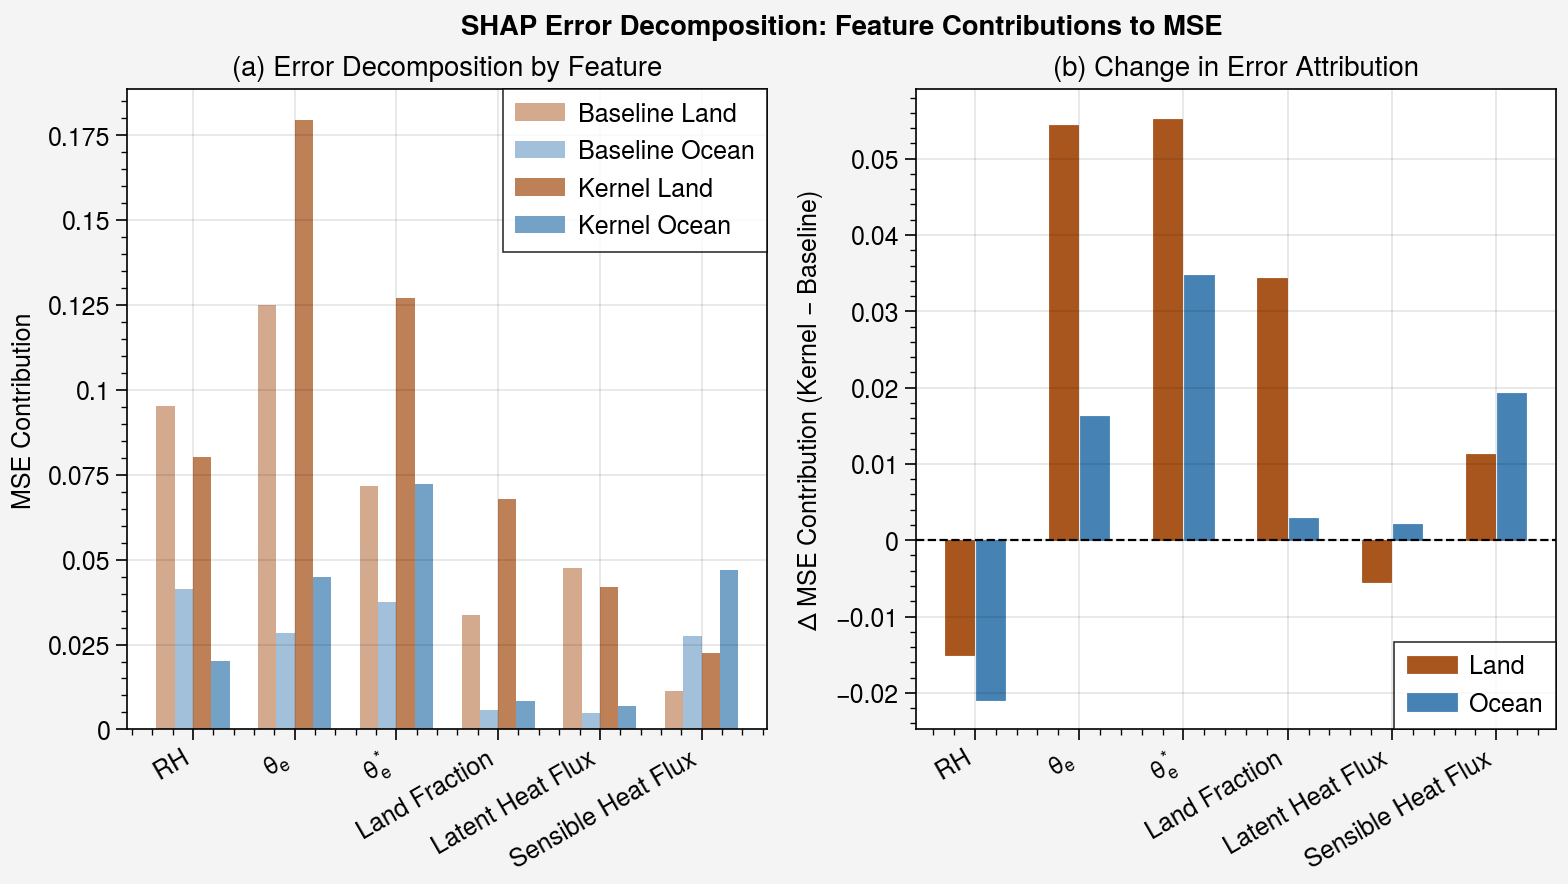

In [17]:
plot_shap_attribution(sv_bl, sv_bo, sv_kl, sv_ko,
                      y_land, y_ocean,
                      yhat_bl, yhat_bo, yhat_kl, yhat_ko,
                      vcols, list(vcols.keys()))

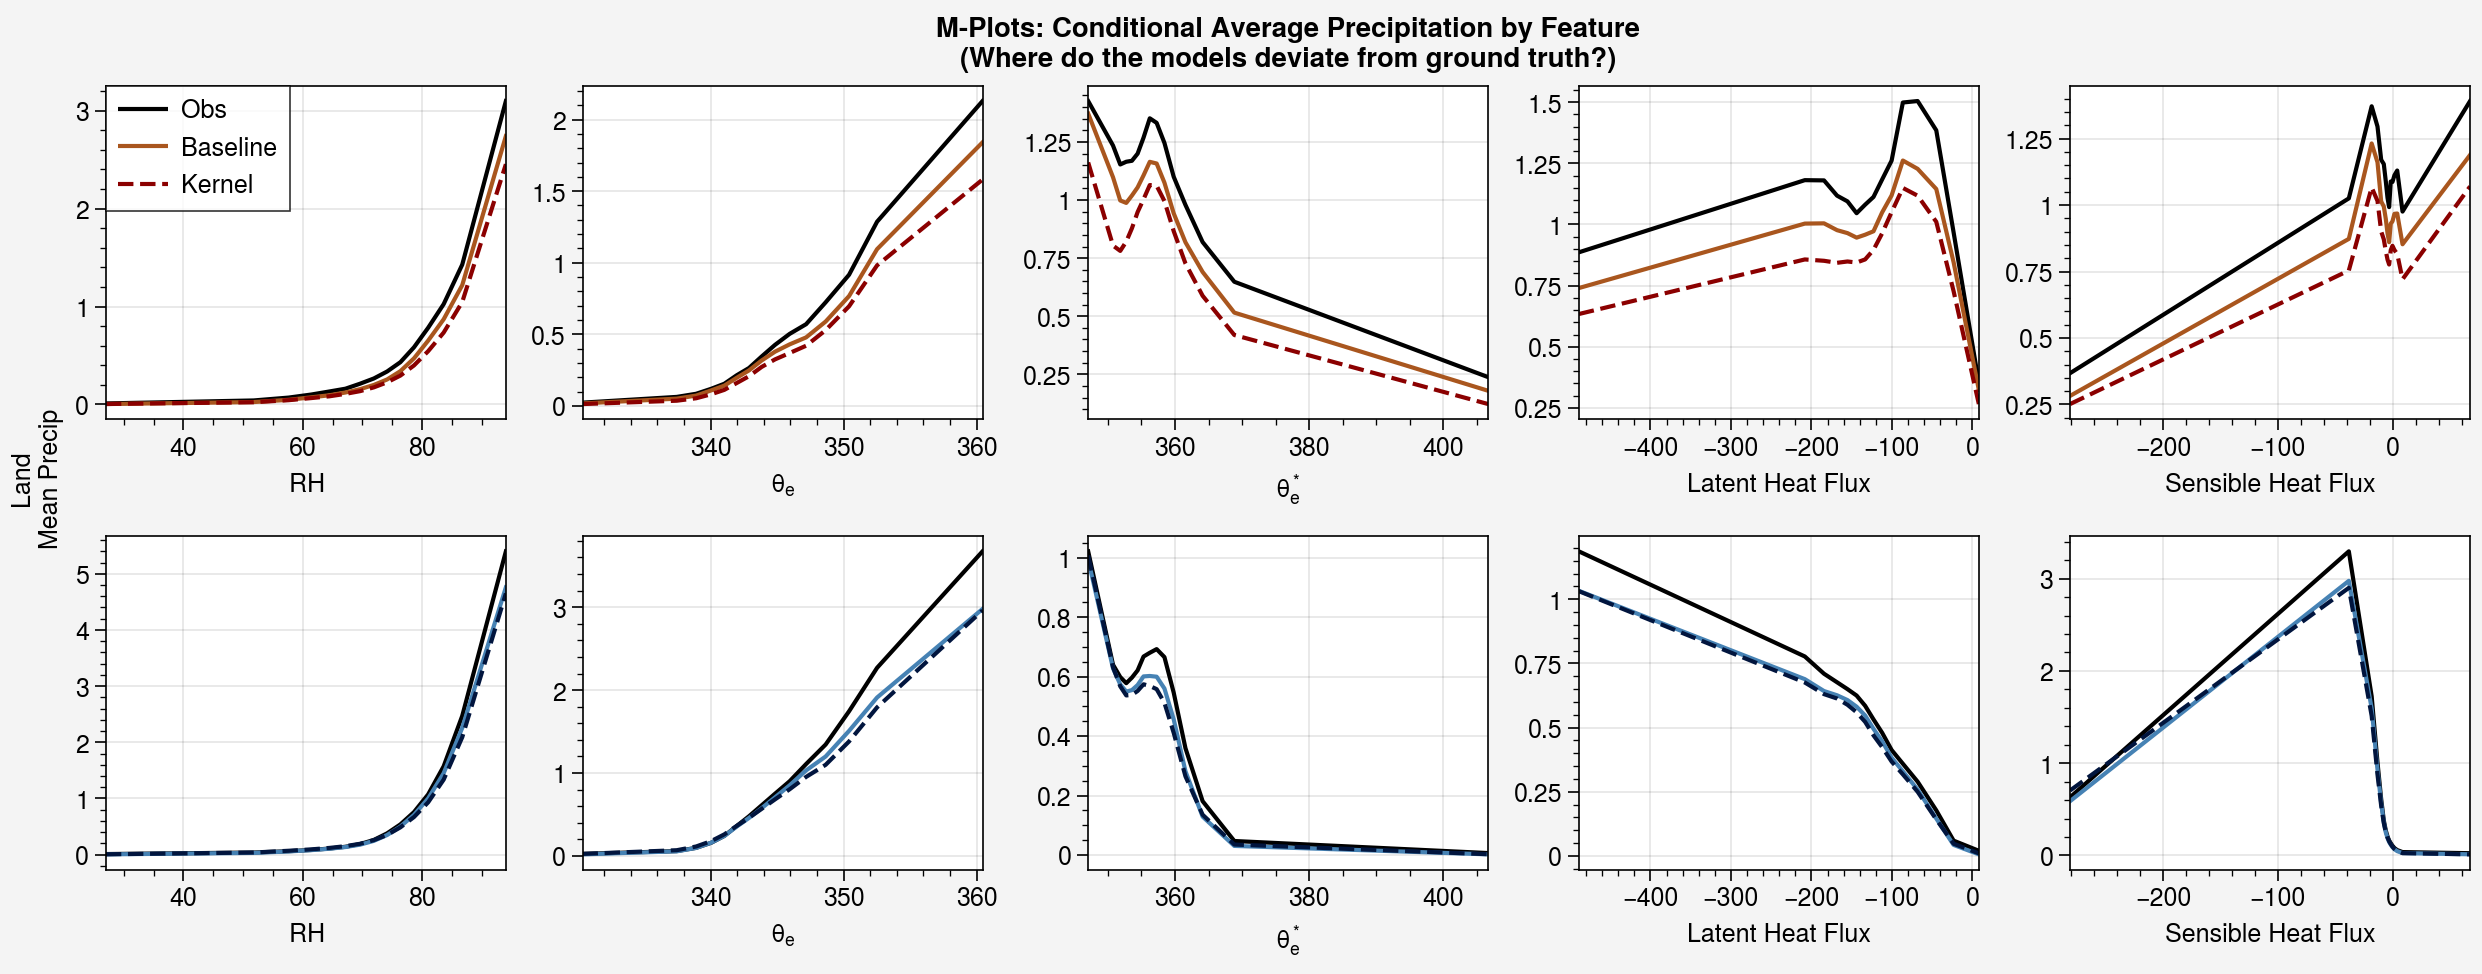

In [18]:
plot_mplots(results,landmask)

In [5]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100,'reso':'xx-hi'})

In [6]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FEATSDIR   = CONFIGS['filepaths']['features']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
FIELDVARS  = CONFIGS['variables']['field'][-3:]
LOCALVARS  = CONFIGS['variables']['local']
SPLIT      = 'valid'
BASENAME   = 'baseline_rh_thetae_thetaestar_lf_lhf_shf'
KERNNAME   = 'nonparametric_rh_thetae_thetaestar_lf_lhf_shf'
VARLABELS  = {
    'rh':'RH',
    'thetae':'$\\mathit{\\theta_{e}}$',
    'thetaestar':'$\\mathit{\\theta_{e}}^*$',
    'lhf':'Latent Heat Flux',
    'shf':'Sensible Heat Flux',
    'lf':'Land Fraction'}
LANDCOLOR  = 'jungle green'
OCEANCOLOR = 'steelblue'

In [9]:
evalds    = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf')
ps        = evalds.ps.load()
landmask  = evalds.lf.load()>0.5

results = {}
for name,_ in NNCONFIG['runs'].items():
    if name not in (BASENAME,KERNNAME):
        continue
    ytrue = evalds.tp.load()
    ypred = xr.open_dataset(os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc'),engine='h5netcdf').tp.load()
    if name == BASENAME:
        field = evalds[FIELDVARS].load()
    else:
        field = xr.open_dataset(os.path.join(FEATSDIR,f'{name}_{SPLIT}_features.nc'),engine='h5netcdf')[FIELDVARS].load()
    local = evalds[LOCALVARS].load()
    align = xr.align(ytrue,ypred,field,local,join='inner')
    ytrue,ypred,field,local = align
    entry = {
        'ytrue':ytrue,
        'ypred':ypred,
        'field':field,
        'local':local}
    if name==KERNNAME:
        entry['weights'] = xr.open_dataset(os.path.join(WEIGHTSDIR,f'{name}_{SPLIT}_weights.nc')).load()
    results[name] = entry

print(f'Loaded {len(results)} models!')

Loaded 2 models!


In [10]:
def get_r2(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    ssr  = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sst  = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return 1-ssr/sst

def bin_land_ocean(x,y,landmask,nbins=50):
    finite = np.isfinite(x)
    binedges   = np.quantile(x[finite],np.linspace(0,1,nbins+1))
    bincenters = 0.5*(binedges[:-1]+binedges[1:])
    landmean,landstd,oceanmean,oceanstd = [],[],[],[]
    for i in range(nbins):
        inrange = (x>=binedges[i])&(x<=binedges[i+1])
        yland  = y[inrange&landmask]
        yocean = y[inrange&~landmask]
        yland  = yland[np.isfinite(yland)]
        yocean = yocean[np.isfinite(yocean)]
        landmean.append(yland.mean() if len(yland) else np.nan)
        landstd.append(yland.std() if len(yland) else np.nan)
        oceanmean.append(yocean.mean() if len(yocean) else np.nan)
        oceanstd.append(yocean.std() if len(yocean) else np.nan)
    return bincenters,np.array(landmean),np.array(landstd),np.array(oceanmean),np.array(oceanstd)

In [14]:
def plot_r2_maps(results):
    base = results[BASENAME]
    kern = results[KERNNAME]
    ytrueb,ypredb = base['ytrue'],base['ypred']
    ytruek,ypredk = kern['ytrue'],kern['ypred']
    r2b  = get_r2(ytrueb,ypredb,dims=['time']).mean('seed').squeeze()
    r2k  = get_r2(ytruek,ypredk,dims=['time']).mean('seed').squeeze()
    diff = r2k-r2b
    fig,axs = pplt.subplots(nrows=1,ncols=3,refwidth=2,proj='cyl',share=False)
    axs.format(grid=False,coast=True,latlim=LATRANGE,lonlim=LONRANGE,
               collabels=['Baseline','Kernel','Kernel $-$ Baseline'])
    axs[0].pcolormesh(r2b.lon,r2b.lat,r2b,cmap='Blues',vmin=0,vmax=0.8,levels=17,extend='max')
    im1 = axs[1].pcolormesh(r2k.lon,r2k.lat,r2k,cmap='Blues',vmin=0,vmax=0.8,levels=17,extend='max')
    im2 = axs[2].pcolormesh(diff.lon,diff.lat,diff,cmap='ColdHot_r',vmin=-0.2,vmax=0.2,levels=9,extend='both')
    fig.colorbar(im1,loc='b',cols=(1,2),label='R$^2$',ticks=0.1)
    fig.colorbar(im2,loc='b',cols=3,label='$\Delta$R$^2$',ticks=0.1)
    pplt.show()
    
def plot_skill_diff_by_predictor(results,landmask,varnames=FIELDVARS+LOCALVARS,nbins=50):
    base = results[BASENAME]
    kern = results[KERNNAME]
    r2b  = get_r2(base['ytrue'],base['ypred'],dims=['time']).mean('seed').squeeze()
    r2k  = get_r2(kern['ytrue'],kern['ypred'],dims=['time']).mean('seed').squeeze()
    diff = r2k-r2b
    fig,axs = pplt.subplots(nrows=2,ncols=len(varnames)//2,refwidth=2,sharex=False,sharey=True)
    axs.format(suptitle='Dependence of Model Skill Improvement on Predictor Value',grid=True,
               ylabel='$\Delta R^2$ (Kernel $-$ Baseline)',ylim=(-0.75,0.25),yticks=0.25)
    for ax,varname in zip(axs,varnames):
        x = base['field'][varname] if varname in FIELDVARS else base['local'][varname]
        xmean = x.mean(dim=[d for d in x.dims if d not in ('lat','lon')])
        bincenters,landmean,landstd,oceanmean,oceanstd = bin_land_ocean(
            xmean.values.ravel(),diff.values.ravel(),landmask.values.ravel(),nbins=nbins)
        ax.fill_between(bincenters,landmean-landstd,landmean+landstd,color=LANDCOLOR,alpha=0.15)
        ax.fill_between(bincenters,oceanmean-oceanstd,oceanmean+oceanstd,color=OCEANCOLOR,alpha=0.15)
        ax.plot(bincenters,landmean,color=LANDCOLOR,linewidth=1.5,label='Land')
        ax.plot(bincenters,oceanmean,color=OCEANCOLOR,linewidth=1.5,label='Ocean')
        ax.axhline(0,color='k',linewidth=0.8,linestyle='--')
        ax.format(xlabel=VARLABELS[varname])
    axs[0].legend(loc='lr',ncols=1)
    pplt.show()

def plot_error_diff_by_ps(results,ps,landmask,nbins=50):
    base = results[BASENAME]
    kern = results[KERNNAME]
    residb = (base['ytrue']-base['ypred']).mean(['time','seed']).squeeze()
    residk = (kern['ytrue']-kern['ypred']).mean(['time','seed']).squeeze()
    diff   = residk-residb
    psmean = ps.mean('time')
    bincenters,landmean,landstd,oceanmean,oceanstd = bin_land_ocean(
        psmean.values.ravel(),diff.values.ravel(),landmask.values.ravel(),nbins=nbins)
    fig,ax = pplt.subplots(nrows=1,ncols=1,refheight=2,refwidth=6)
    ax.format(suptitle='Dependence of Model Error Difference on Surface Pressure',grid=True,
              xlabel='Surface Pressure (hPa)',ylabel='Difference in Mean Prediction\nError (Kernel $-$ Baseline)')
    ax.fill_between(bincenters,landmean-landstd,landmean+landstd,color=LANDCOLOR,alpha=0.15)
    ax.fill_between(bincenters,oceanmean-oceanstd,oceanmean+oceanstd,color=OCEANCOLOR,alpha=0.15)
    ax.plot(bincenters,landmean,color=LANDCOLOR,linewidth=1.5,label='Land')
    ax.plot(bincenters,oceanmean,color=OCEANCOLOR,linewidth=1.5,label='Ocean')
    ax.axhline(0,color='k',linewidth=0.8,ls='--')
    ax.legend(loc='ur',ncols=1)
    pplt.show()

def plot_predictor_variance(results,landmask):
    base = results[BASENAME]
    kern = results[KERNNAME]
    fig,axs = pplt.subplots(nrows=2,ncols=len(FIELDVARS),refwidth=1.8,sharex=False,sharey=1)
    axs.format(suptitle='Temporal Variability of Raw vs. Kernel-Integrated Field Predictors',grid=True,
               ylabel='Density',rowlabels=['Raw','Kernel-Integrated'])
    for col,varname in enumerate(FIELDVARS):
        isfield = varname in FIELDVARS
        for row,(label,src) in enumerate([('raw',base),('kern',kern)]):
            ax = axs[row,col]
            if row==1:
                ax.format(xlabel=f'Temporal $\sigma$ of {VARLABELS[varname]}')
            x = src['field'][varname] if isfield else src['local'][varname]
            if 'seed' in x.dims:
                x = x.mean('seed')
            varstd = x.std(dim=[d for d in x.dims if d not in ('lat','lon')])
            bins   = np.linspace(np.nanmin(varstd.values),np.nanmax(varstd.values),50)
            landvalues  = varstd.where(landmask).values.ravel()
            oceanvalues = varstd.where(~landmask).values.ravel()
            landvalues  = landvalues[np.isfinite(landvalues)]
            oceanvalues = oceanvalues[np.isfinite(oceanvalues)]
            ax.hist(landvalues,bins=bins,color=LANDCOLOR,alpha=0.5,density=True,label='Land')
            ax.hist(oceanvalues,bins=bins,color=OCEANCOLOR,alpha=0.5,density=True,label='Ocean')
    axs[0,0].legend(loc='ur',ncols=1)
    pplt.show()

def plot_weights(results):
    kern    = results[KERNNAME]
    weights = kern['weights']
    levels  = weights['lev'].values
    fig,axs = pplt.subplots(nrows=1,ncols=len(FIELDVARS),refheight=2,refwidth=1,share=True)
    axs.format(suptitle='Nonparametric Kernel Weights',grid=True,
               xlabel='Normalized Kernel Weight',ylabel='Pressure (hPa)')
    for ax,varname in zip(axs,FIELDVARS):
        wmean = weights['k1'].sel(field=varname).mean('seed').values
        wstd  = weights['k1'].sel(field=varname).std('seed').values
        ax.plot(wmean,levels,color='k',linewidth=1.5)
        ax.fill_betweenx(levels,wmean-wstd,wmean+wstd,color='k',alpha=0.2)
        ax.axvline(0,color='k',linewidth=0.8,linestyle='--')
        ax.format(title=VARLABELS[varname],xlim=(-0.005,0.008),yreverse=True)
    pplt.show()

In [50]:
# plot_r2_maps(results)

In [51]:
# plot_skill_diff_by_predictor(results,landmask)

In [52]:
# plot_error_diff_by_ps(results,ps,landmask)

In [53]:
# plot_predictor_variance(results,landmask)

In [54]:
# plot_weights(results)

In [55]:
import shap
import torch
import sys
sys.path.insert(0,os.path.abspath('..'))
from scripts.models.nn.classes.factory import build_model
from scripts.models.nn.classes.dataset import load_split

F,L,Y,dlev,nlevs,_,validshap,_ = load_split(SPLIT,FIELDVARS,LOCALVARS,SPLITSDIR,targetvar='tp')
nfv,nlv = len(FIELDVARS),len(LOCALVARS)
Xshap   = np.hstack([F.numpy().reshape(len(F),-1),L.numpy()])
island  = L[:,0].numpy()>0.5

vcols = {}
for i,v in enumerate(FIELDVARS):
    vcols[v] = slice(i*nlevs,(i+1)*nlevs)
for j,v in enumerate(LOCALVARS):
    vcols[v] = slice(nfv*nlevs+j,nfv*nlevs+j+1)


In [56]:
def errdecomp(sv,ytrue,ypred,vcols):
    sqerr = (ypred-ytrue)**2
    abssv = np.abs(sv)
    total = abssv.sum(axis=1,keepdims=True)
    total = np.where(total==0,1,total)
    wt    = abssv/total*sqerr[:,np.newaxis]
    return {v:wt[:,vcols[v]].sum(axis=1).mean() for v in vcols}

def plot_shap_error(svbl,svbo,svkl,svko,yland,yocean,
                    yhatbl,yhatbo,yhatkl,yhatko,vcols,allvars):
    labels = [VARLABELS.get(v,v) for v in allvars]
    xp,w   = np.arange(len(allvars)),0.18
    edbl = errdecomp(svbl,yland, yhatbl,vcols)
    edbo = errdecomp(svbo,yocean,yhatbo,vcols)
    edkl = errdecomp(svkl,yland, yhatkl,vcols)
    edko = errdecomp(svko,yocean,yhatko,vcols)
    fig,axs = pplt.subplots(ncols=2,refwidth=2,share=False)
    for i,(ml,edl,edo) in enumerate([('Baseline',edbl,edbo),('Kernel',edkl,edko)]):
        for j,(sl,ed,c) in enumerate([('Land',edl,LANDCOLOR),('Ocean',edo,OCEANCOLOR)]):
            axs[0].bar(xp+(i*2+j-1.5)*w,[ed[v] for v in allvars],width=w,color=c,
                       alpha=0.5+0.25*i,label=f'{ml} {sl}')
    axs[0].set_xticks(xp)
    axs[0].set_xticklabels(labels,rotation=30,ha='right')
    axs[0].format(ylabel='MSE Contribution',title='(a) Error Decomposition by Feature',grid=True)
    axs[0].legend(loc='ur',ncols=1,fontsize=7)
    diffland  = {v:edkl[v]-edbl[v] for v in vcols}
    diffocean = {v:edko[v]-edbo[v] for v in vcols}
    axs[1].bar(xp-0.15,[diffland[v]  for v in allvars],width=0.28,color=LANDCOLOR, label='Land')
    axs[1].bar(xp+0.15,[diffocean[v] for v in allvars],width=0.28,color=OCEANCOLOR,label='Ocean')
    axs[1].axhline(0,color='k',linewidth=0.8,linestyle='--')
    axs[1].set_xticks(xp)
    axs[1].set_xticklabels(labels,rotation=30,ha='right')
    axs[1].format(ylabel=r'$\Delta$ MSE Contribution (Kernel $-$ Baseline)',
                  title='(b) Change in Error Attribution',grid=True)
    axs[1].legend(loc='lr',ncols=1,fontsize=7)
    fig.format(suptitle='SHAP Error Decomposition: Feature Contributions to MSE')
    pplt.show()

def plot_mplots(results,landmask,nbins=15):
    base = results[BASENAME]
    kern = results[KERNNAME]
    obs,basepred,kernpred = xr.align(base['ytrue'],
        base['ypred'].mean('seed') if 'seed' in base['ypred'].dims else base['ypred'],
        kern['ypred'].mean('seed') if 'seed' in kern['ypred'].dims else kern['ypred'],
        join='inner')
    obs,basepred,kernpred = obs.squeeze(),basepred.squeeze(),kernpred.squeeze()
    pvars = FIELDVARS+[v for v in LOCALVARS if v!='lf']
    feats = {}
    for vn in pvars:
        x = base['field'][vn] if vn in FIELDVARS else base['local'][vn]
        extra = [d for d in x.dims if d not in ('time','lat','lon')]
        if extra:
            x = x.mean(dim=extra)
        feats[vn],_ = xr.align(x,obs,join='inner')
    lm = landmask.reindex_like(obs,method=None).broadcast_like(obs)
    ds = xr.Dataset({'obs':obs,'base':basepred,'kern':kernpred,'lm':lm})
    for vn in pvars:
        ds[f'f_{vn}'] = feats[vn]
    stk    = ds.stack(sample=obs.dims).dropna('sample',subset=['obs'])
    fo,fb,fk = stk['obs'].values,stk['base'].values,stk['kern'].values
    lmflat   = stk['lm'].values.astype(bool)
    fig,axs = pplt.subplots(nrows=2,ncols=len(pvars),refwidth=2,refaspect=1.2,sharex=False,sharey='labels')
    axs.format(grid=True)
    for col,vn in enumerate(pvars):
        ff    = stk[f'f_{vn}'].values
        ok    = np.isfinite(ff)&np.isfinite(fo)
        edges = np.quantile(ff[ok],np.linspace(0,1,nbins+1))
        ctrs  = 0.5*(edges[:-1]+edges[1:])
        for row,(stype,smask) in enumerate([('Land',lmflat),('Ocean',~lmflat)]):
            ax = axs[row,col]
            mobs,mbase,mkern = [],[],[]
            for i in range(nbins):
                sel = ok&smask&(ff>=edges[i])&(ff<=edges[i+1])
                if sel.sum()>10:
                    mobs.append(fo[sel].mean())
                    mbase.append(fb[sel].mean())
                    mkern.append(fk[sel].mean())
                else:
                    mobs.append(np.nan)
                    mbase.append(np.nan)
                    mkern.append(np.nan)
            lc = LANDCOLOR if stype=='Land' else OCEANCOLOR
            kc = 'darkred'  if stype=='Land' else 'navy'
            ax.plot(ctrs,mobs,'k-',linewidth=1.5,label='Obs')
            ax.plot(ctrs,mbase,'-', linewidth=1.5,color=lc,label='Baseline')
            ax.plot(ctrs,mkern,'--',linewidth=1.5,color=kc,label='Kernel')
            ax.format(xlabel=VARLABELS.get(vn,vn))
            if col==0:
                ax.format(ylabel=f'{stype}\nMean Precip')
            if row==0 and col==0:
                ax.legend(loc='ul',ncols=1,fontsize=7)
    fig.format(suptitle='M-Plots: Conditional Average Precipitation by Feature')
    pplt.show()


In [57]:
rng = np.random.default_rng(42)

def loadmodel(name):
    rc  = NNCONFIG['runs'][name]
    mdl = build_model(name,rc,nlevs)
    mdl.load_state_dict(torch.load(
        os.path.join(MODELSDIR,'nn',f'{name}_42.pth'),
        map_location='cpu',weights_only=True))
    mdl.eval()
    return mdl,rc['kind'] not in ('baseline','hurdle')

modelbase,hkbase = loadmodel(BASENAME)
modelkern,hkkern = loadmodel(KERNNAME)

def makepredictfn(mdl,haskernel):
    def predict(x):
        x = np.atleast_2d(x).astype(np.float32)
        n = x.shape[0]
        ft = torch.from_numpy(x[:,:nfv*nlevs].reshape(n,nfv,nlevs))
        lt = torch.from_numpy(x[:,nfv*nlevs:])
        with torch.no_grad():
            out = mdl(ft,dlev,lt,mask=None) if haskernel else mdl(ft,lt,mask=torch.ones(n,nlevs))
        return np.atleast_1d(out.numpy())
    return predict

fnbase = makepredictfn(modelbase,hkbase)
fnkern = makepredictfn(modelkern,hkkern)

landidx   = np.where(island)[0]
oceanidx  = np.where(~island)[0]
bgdata    = Xshap[rng.choice(len(Xshap),NBG,replace=False)]
landsamp  = rng.choice(landidx, min(NEX,len(landidx)), replace=False)
oceansamp = rng.choice(oceanidx,min(NEX,len(oceanidx)),replace=False)

print(f'Kernel SHAP: {Xshap.shape[1]} features, '
      f'{len(landsamp)} land + {len(oceansamp)} ocean samples, {NSAMP} coalitions')

expbase = shap.KernelExplainer(fnbase,bgdata)
expkern = shap.KernelExplainer(fnkern,bgdata)

print('  Baseline - land ...')
svbl = expbase.shap_values(Xshap[landsamp], nsamples=NSAMP,silent=True)
print('  Baseline - ocean ...')
svbo = expbase.shap_values(Xshap[oceansamp],nsamples=NSAMP,silent=True)
print('  Kernel - land ...')
svkl = expkern.shap_values(Xshap[landsamp], nsamples=NSAMP,silent=True)
print('  Kernel - ocean ...')
svko = expkern.shap_values(Xshap[oceansamp],nsamples=NSAMP,silent=True)

yland  = Y[landsamp].numpy().ravel()
yocean = Y[oceansamp].numpy().ravel()
yhatbl = fnbase(Xshap[landsamp]).ravel()
yhatbo = fnbase(Xshap[oceansamp]).ravel()
yhatkl = fnkern(Xshap[landsamp]).ravel()
yhatko = fnkern(Xshap[oceansamp]).ravel()
print('Done.')


NameError: name 'NBG' is not defined

In [ ]:
plot_shap_error(svbl,svbo,svkl,svko,yland,yocean,yhatbl,yhatbo,yhatkl,yhatko,vcols,list(vcols.keys()))


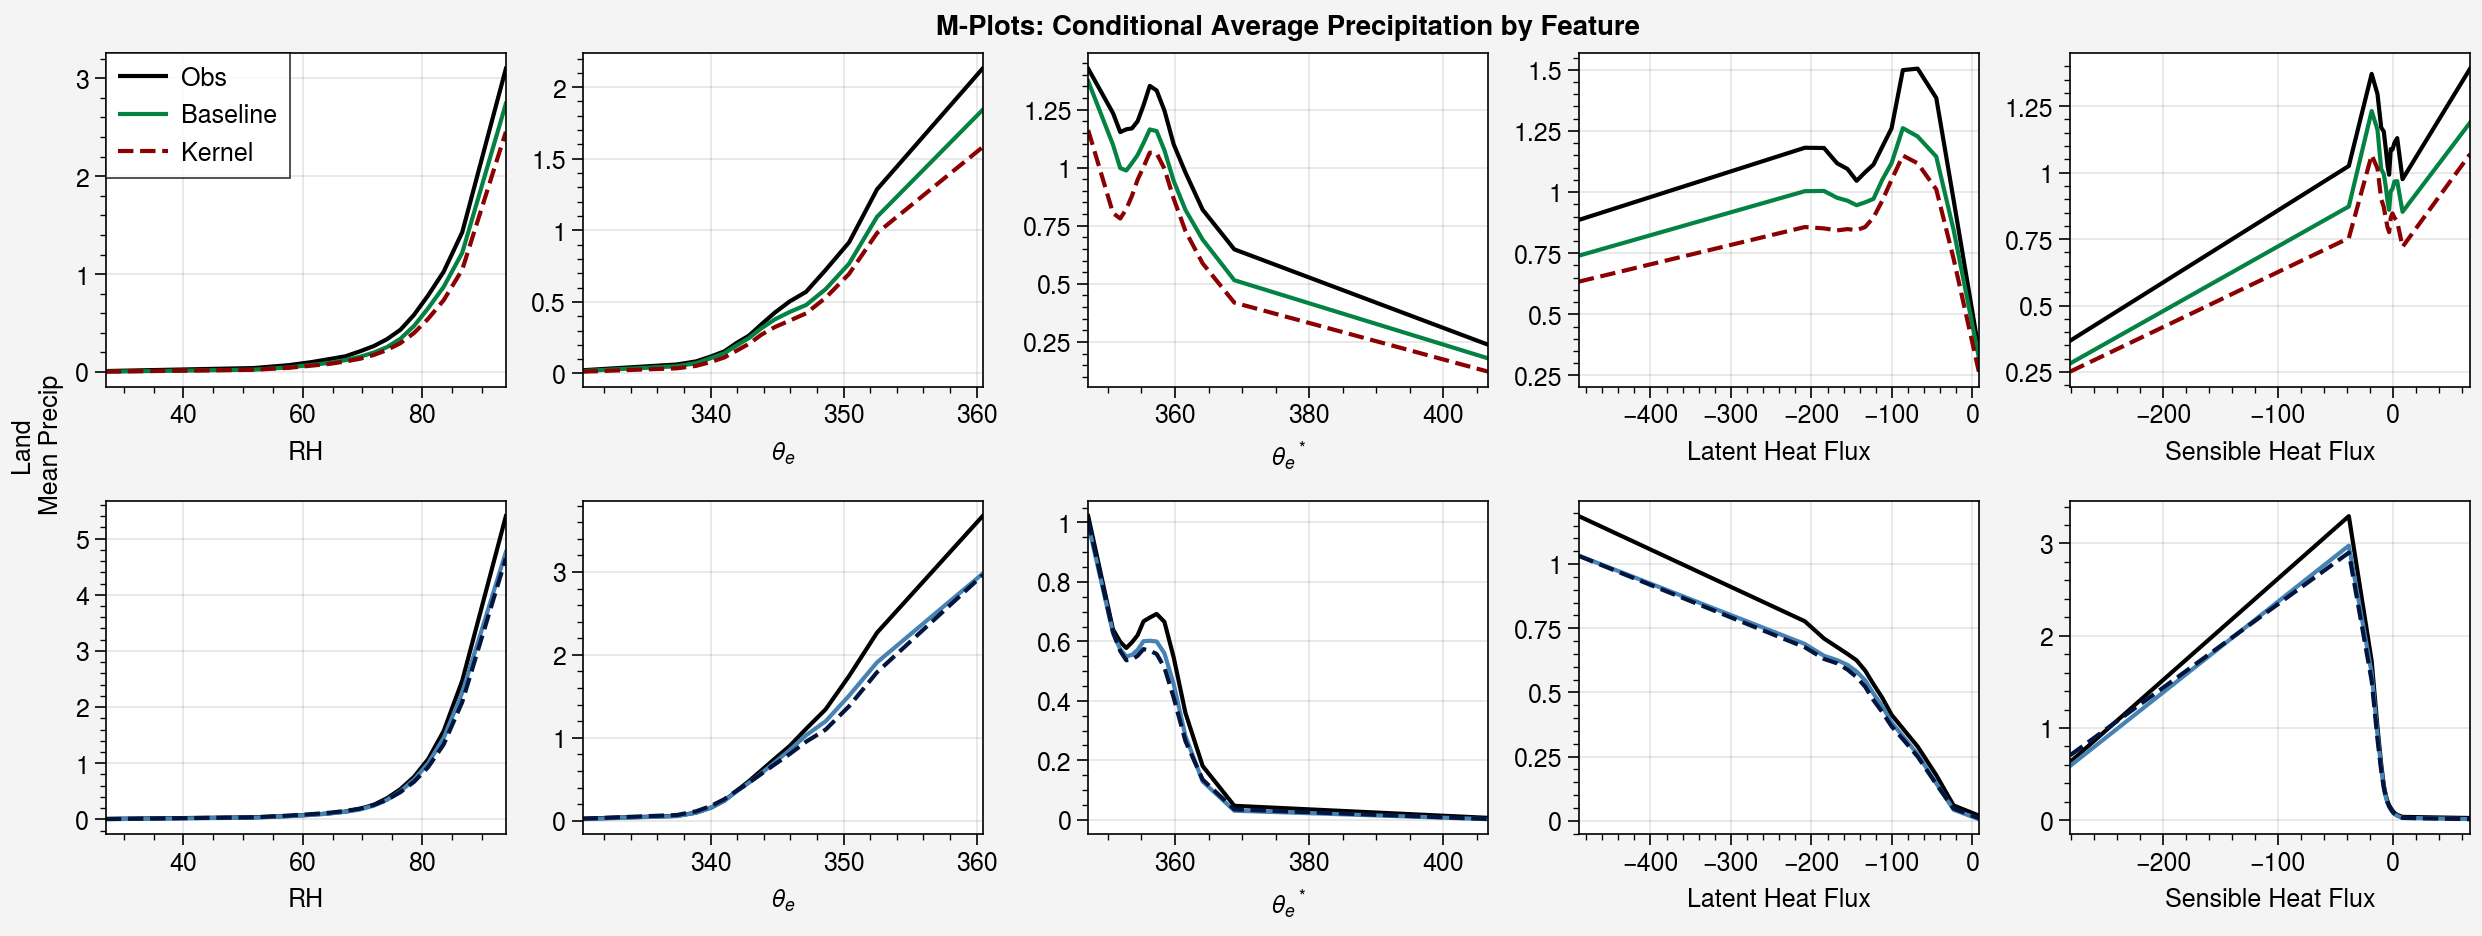

In [58]:
plot_mplots(results,landmask)
